In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import shutil

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

# catboost
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# xg boost
try:
    import xgboost as xbm
except:
    ! pip install xgboost
    import xgboost as xbm

(CVXPY) Dec 16 09:09:13 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Dec 16 09:09:13 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
# get pmt hx
def make_auto_pmt_hx_df(ser_row):
    # replace nan with None
    ser_row = ser_row.str.replace('nan', 'None')
    # convert to lists
    ser_row = ser_row.apply(eval)
    # make into dictionary
    dict_ser_row = dict(ser_row)
    # make df
    try:
        df_tmp = pd.DataFrame(dict_ser_row)
    except ValueError:
        dict_output = {
            # overall
            'flt_mean_months_to_first_bad': np.nan,
            # open
            'flt_payment_open': np.nan,
            'int_n_months_open': np.nan,
            'list_pmt_hx_open': np.nan,
            'flt_wtd_avg_open': np.nan,
            'flt_avg_open': np.nan,
            'int_30dpd_open': np.nan,
            'int_60dpd_open': np.nan,
            'int_90dpd_open': np.nan,
            # closed
            'flt_payment_closed': np.nan,
            'int_n_months_closed': np.nan,
            'list_pmt_hx_closed': np.nan,
            'flt_wtd_avg_closed': np.nan,
            'flt_avg_closed': np.nan,
            'int_30dpd_closed': np.nan,
            'int_60dpd_closed': np.nan,
            'int_90dpd_closed': np.nan,
        }
        # return
        return dict_output
    
    # get only auto
    df_tmp = df_tmp[df_tmp['auto__tu_pmthx'] == 1].copy()
    
    # columns
    list_cols = [
        'str_dtm_opened__tu_pmthx',
        'str_dtm_closed__tu_pmthx',
        'str_dtm_most_recent_pmt__tu_pmthx',
    ]
    # make dtm
    for col in list_cols:
        # make str_dtm_opened__tu_pmthx a datetime
        df_tmp[col] = pd.to_datetime(df_tmp[col])
    # sort
    df_tmp.sort_values(by='str_dtm_opened__tu_pmthx', ascending=False, inplace=True)
    
    # tag open
    df_tmp['tag_open'] = df_tmp['str_dtm_closed__tu_pmthx'].apply(
        lambda x: 1 if pd.isnull(x) else 0,
    )
    
    # fillna
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].fillna('')
    
    # get n payments
    df_tmp['n_months'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: len(x),
    )
    
    # convert str_pmt_hx__tu_pmthx to lists of 1 and 0
    df_tmp['str_pmt_hx__tu_pmthx'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
        lambda x: [1 if str_val == '1' else 0 for str_val in list(x)],
    )
    # first month of bad event
    df_tmp['month_first_bad'] = df_tmp['str_pmt_hx__tu_pmthx'].apply(
         lambda x: pd.Series(list(x))[pd.Series(list(x)) != 1].index.min()+1,
    )
    # months to first bad
    df_tmp['months_to_first_bad'] = df_tmp['month_first_bad'].fillna(df_tmp['n_months'])
    # make it a proportion
    df_tmp['months_to_first_bad'] = df_tmp['months_to_first_bad'] / df_tmp['n_months']
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    
    # get mean proportion months to first bad overall open and closed - all
    flt_mean_months_to_first_bad = df_tmp['months_to_first_bad'].mean()
    # logic if there is no payment history
    if pd.isnull(flt_mean_months_to_first_bad):
        flt_mean_months_to_first_bad = 0 # lower is worse it means you have early delinquency
    else:
        pass
    
    # get df open
    df_tmp_open = df_tmp[df_tmp['tag_open'] == 1].copy()
    int_nrows = df_tmp_open.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_open = df_tmp_open['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_open = df_tmp_open['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_open = df_tmp_open['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_open)+1))
        try:
            flt_wtd_avg_open = np.average(list_pmt_hx_open, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_open = np.nan # lower is worse
        # get normal average
        flt_avg_open = np.mean(list_pmt_hx_open)
        # get DPD
        int_30dpd_open = df_tmp_open['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_open = df_tmp_open['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_open = df_tmp_open['flt_90_dpd__tu_pmthx'].iloc[0]
    else:
        flt_payment_open = np.nan
        int_n_months_open = np.nan
        list_pmt_hx_open = np.nan
        flt_wtd_avg_open = np.nan
        flt_avg_open = np.nan
        int_30dpd_open = np.nan
        int_60dpd_open = np.nan
        int_90dpd_open = np.nan
    
    # get df closed
    df_tmp_closed = df_tmp[df_tmp['tag_open'] == 0].copy()
    int_nrows = df_tmp_closed.shape[0]
    if int_nrows > 0:
        # get mayment
        flt_payment_closed = df_tmp_closed['flt_payment__tu_pmthx'].iloc[0]
        # get n months
        int_n_months_closed = df_tmp_closed['n_months'].iloc[0]
        # get the most recent open pmt hx
        list_pmt_hx_closed = df_tmp_closed['str_pmt_hx__tu_pmthx'].iloc[0]
        # get weighted average
        list_weights = list(range(1, len(list_pmt_hx_closed)+1))
        try:
            flt_wtd_avg_closed = np.average(list_pmt_hx_closed, weights=list_weights)
        except ZeroDivisionError:
            flt_wtd_avg_closed = np.nan
        # get normal average
        flt_avg_closed = np.mean(list_pmt_hx_closed)
        # get DPD
        int_30dpd_closed = df_tmp_closed['flt_30_dpd__tu_pmthx'].iloc[0]
        int_60dpd_closed = df_tmp_closed['flt_60_dpd__tu_pmthx'].iloc[0]
        int_90dpd_closed = df_tmp_closed['flt_90_dpd__tu_pmthx'].iloc[0]
    else:
        flt_payment_closed = np.nan
        int_n_months_closed = np.nan
        list_pmt_hx_closed = np.nan
        flt_wtd_avg_closed = np.nan
        flt_avg_closed = np.nan
        int_30dpd_closed = np.nan
        int_60dpd_closed = np.nan
        int_90dpd_closed = np.nan
    
    # dict output
    dict_output = {
        # overall
        'flt_mean_months_to_first_bad': flt_mean_months_to_first_bad,
        # open
        'flt_payment_open': flt_payment_open,
        'int_n_months_open': int_n_months_open,
        'list_pmt_hx_open': list_pmt_hx_open,
        'flt_wtd_avg_open': flt_wtd_avg_open,
        'flt_avg_open': flt_avg_open,
        'int_30dpd_open': int_30dpd_open,
        'int_60dpd_open': int_60dpd_open,
        'int_90dpd_open': int_90dpd_open,
        # closed
        'flt_payment_closed': flt_payment_closed,
        'int_n_months_closed': int_n_months_closed,
        'list_pmt_hx_closed': list_pmt_hx_closed,
        'flt_wtd_avg_closed': flt_wtd_avg_closed,
        'flt_avg_closed': flt_avg_closed,
        'int_30dpd_closed': int_30dpd_closed,
        'int_60dpd_closed': int_60dpd_closed,
        'int_90dpd_closed': int_90dpd_closed,
    }
    
    # return
    return dict_output

#### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

Project: 20241112-simple-model-test
Task: 09_15_in_60
Subtask: 03_get_predictions


#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [5]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,flt_past_due__tu_pmthx,flt_30_dpd__tu_pmthx,flt_60_dpd__tu_pmthx,flt_90_dpd__tu_pmthx,str_loan_type__tu_pmthx,str_pmt_hx__tu_pmthx,str_dtm_most_recent_pmt__tu_pmthx,str_method__tu_pmthx,auto__tu_pmthx,flt_sec
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493,10452716,1,Ohio,...,"[252.0, 486.0, 250.0, 2000.0, 0.0, 3076.0, 0.0...","[1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 0.0, nan, nan, ...","[1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, nan, nan, ...","[0.0, 2.0, 0.0, 4.0, 0.0, 2.0, 0.0, nan, nan, ...","['LC', 'CC', 'CC', 'AU', 'AU', 'AU', 'SC', 'ST...","['LLLLLLLLLLLLLLLL321', 'LLLLLLLLLLLLLLLLLLLLL...","[nan, nan, nan, '2024-01-29', '2020-01-02', '2...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0.161885
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030,10419180,1,Virginia,...,"[482.0, 11924.0, 0.0, 15.0, 0.0, 0.0, 0.0, 0.0...","[3.0, 2.0, 2.0, 1.0, 0.0, 3.0, 0.0, 1.0, 0.0, ...","[1.0, 1.0, 2.0, 1.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[1.0, 1.0, 4.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","['AU', 'US', 'CH', 'CC', 'CC', 'CC', 'CC', 'CC...",['LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL4322211111111...,"['2021-12-29', '2022-02-25', '2023-02-23', '20...","['automated', 'automated', 'automated', 'autom...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.102787
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326,10415994,1,Utah,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.075270
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439,10446729,1,Texas,...,"[121.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, nan, 0.0, 1.0, 1.0, 1.0]","[1.0, 0.0, nan, 0.0, 0.0, 1.0, 0.0]","[0.0, 30.0, nan, 0.0, 0.0, 0.0, 0.0]","['CC', 'CP', 'SC', 'LC', 'SE', 'SE', 'SE']","['3211', '1155555555555555555Y5555555555555', ...","[nan, '2024-09-30', nan, '2024-09-24', '2022-0...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 0, 0, 0, 0]",0.095339
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168,10441665,1,Colorado,...,"[3600.0, 0.0, 366.0, 0.0, 498.0, 0.0, 0.0, 0.0...","[4.0, 2.0, 0.0, 2.0, 2.0, 13.0, 0.0, 0.0, 0.0,...","[3.0, 2.0, 0.0, 3.0, 1.0, 7.0, 0.0, 0.0, 0.0, ...","[2.0, 4.0, 0.0, 2.0, 0.0, 5.0, 0.0, 0.0, 0.0, ...","['AU', 'CH', 'CU', 'SE', 'NT', 'AU', 'AU', 'US...",['LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL...,"['2022-03-18', '2019-10-13', nan, '2021-08-10'...","['automated', 'automated', 'automated', 'autom...","[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.097532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164,10397758,1,Kansas,...,"[0.0, nan, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","['US', 'FR', 'LC', 'CC', 'CC', 'CC', 'CC', 'CC...","['32111', 'XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...","['2021-11-05', '2024-10-25', '2019-01-18', '20...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.100632
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216,10418204,1,Alabama,...,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","['SE', 'CC', 'SE']","['111', '1E', '1']","['2024-10-25', '2024-11-04', '2024-06-28']","['automated', 'automated', 'automated']","[0, 0, 0]",0.095197
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-X

#### Engineer pmt hx

In [6]:
%%time

# pmt history columns
list_cols_pmt_hx = [col for col in df.columns if '__tu_pmthx' in col]
# get pmt hx
df['pmt_hx'] = df[list_cols_pmt_hx].apply(
    lambda x: make_auto_pmt_hx_df(ser_row=x),
    axis=1,
)

# get the pmt hx
df_tmp = pd.DataFrame(list(df['pmt_hx']))
list_cols = [f'{col}__tu_pmthx' for col in df_tmp.columns]
df_tmp.columns = list_cols
# reset index
df = df.reset_index(drop=True)
df_tmp = df_tmp.reset_index(drop=True)
# concat
df = pd.concat([df, df_tmp], axis=1)

# show
df

CPU times: user 12.5 s, sys: 26.6 ms, total: 12.5 s
Wall time: 12.5 s


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,int_60dpd_open__tu_pmthx,int_90dpd_open__tu_pmthx,flt_payment_closed__tu_pmthx,int_n_months_closed__tu_pmthx,list_pmt_hx_closed__tu_pmthx,flt_wtd_avg_closed__tu_pmthx,flt_avg_closed__tu_pmthx,int_30dpd_closed__tu_pmthx,int_60dpd_closed__tu_pmthx,int_90dpd_closed__tu_pmthx
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493,10452716,1,Ohio,...,1.0,2.0,NaN,16.0,"[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.845588,0.625000,1.0,1.0,4.0
1,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030,10419180,1,Virginia,...,NaN,NaN,NaN,20.0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.000000,1.000000,0.0,0.0,0.0
2,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326,10415994,1,Utah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439,10446729,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168,10441665,1,Colorado,...,NaN,NaN,NaN,78.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.893216,0.679487,13.0,7.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164,10397758,1,Kansas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1190,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216,10418204,1,Alabama,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1191,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017,10416818,1,Michigan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1192,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931,10452049,1,California,...,0.0,0.0,NaN,47.0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.000000,1.000000,0.0,0.0,0.0


#### Prep data

In [7]:
# get script
str_filename = 'preprocessing.py'
str_origin = f'../../08_prep_data/{str_filename}'
str_destination = f'./{str_filename}'
shutil.copyfile(str_origin, str_destination)

# read preprocessor
str_filename = 'cls_model_preprocessing.pkl'
str_local_path = f'../../08_prep_data/output/{str_filename}'
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

# preprocess
df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

Masking negative values to NaN...


100%|██████████| 31/31 [00:00<00:00, 1186.05it/s]


Replacing zeros...


100%|██████████| 2/2 [00:00<00:00, 1431.01it/s]


Rounding values...


...

Engineering franchise...
Engineering has a codebtor...
Engineering vehicle age...
Capping income...
Engineering PTI...
Engineering LTV...
Engineering BK...
Imputing values...


0it [00:00, ?it/s]


Binning values...


0it [00:00, ?it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,int_30dpd_closed__tu_pmthx,int_60dpd_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,dti__app
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493,10452716,1,Ohio,...,1.0,1.0,4.0,1,0,-1,NaN,1.066624,0,6.717
1,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030,10419180,1,Virginia,...,0.0,0.0,0.0,0,0,3,0.057423,1.189305,0,6.717
2,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326,10415994,1,Utah,...,NaN,NaN,NaN,1,0,4,NaN,0.839898,0,6.717
3,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439,10446729,1,Texas,...,NaN,NaN,NaN,1,0,3,NaN,1.122613,0,6.717
4,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168,10441665,1,Colorado,...,13.0,7.0,5.0,1,0,3,NaN,1.067790,0,6.717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164,10397758,1,Kansas,...,NaN,NaN,NaN,1,0,4,NaN,1.364394,1,6.717
1190,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216,10418204,1,Alabama,...,NaN,NaN,NaN,1,0,-1,NaN,1.154590,0,6.717
1191,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017,10416818,1,Michigan,...,NaN,NaN,NaN,1,0,2,NaN,1.244700,0,6.717
1192,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931,10452049,1,California,...,0.0,0.0,0.0,0,0,5,0.131666,1.173589,0,6.717


#### Get imputation dictionary

In [8]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

#### Impute

In [9]:
for key, val in tqdm(dict_impute.items()):
    df[key] = df[key].fillna(val)

100%|██████████| 50/50 [00:00<00:00, 2511.77it/s]


#### Predictions from scorecard

In [10]:
# load model
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)

# load binner
str_filename = 'dict_bins.pkl'
str_local_path = f'../02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# bin
df_tmp = df.copy()
for key, val in tqdm(dict_bins.items()):
    df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])

# predict
df['yhat_ml_logistic_scorecard'] = cls_model_inference.predict_proba(df_tmp[list_cols_model])[:,1]
# save memory
del df_tmp
# show
df

100%|██████████| 25/25 [00:00<00:00, 1075.61it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,int_60dpd_closed__tu_pmthx,int_90dpd_closed__tu_pmthx,ENG-franchise,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,dti__app,yhat_ml_logistic_scorecard
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493,10452716,1,Ohio,...,1.0,4.0,1,0,-1,402.000000,1.066624,0,6.717,0.322264
1,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030,10419180,1,Virginia,...,0.0,0.0,0,0,3,0.057423,1.189305,0,6.717,0.094850
2,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326,10415994,1,Utah,...,46.0,54.0,1,0,4,402.000000,0.839898,0,6.717,0.225937
3,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439,10446729,1,Texas,...,46.0,54.0,1,0,3,402.000000,1.122613,0,6.717,0.309534
4,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168,10441665,1,Colorado,...,7.0,5.0,1,0,3,402.000000,1.067790,0,6.717,0.232310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164,10397758,1,Kansas,...,46.0,54.0,1,0,4,402.000000,1.364394,1,6.717,0.152566
1190,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216,10418204,1,Alabama,...,46.0,54.0,1,0,-1,402.000000,1.154590,0,6.717,0.301692
1191,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017,10416818,1,Michigan,...,46.0,54.0,1,0,2,402.000000,1.244700,0,6.717,0.214918
1192,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931,10452049,1,California,...,0.0,0.0,0,0,5,0.131666,1.173589,0,6.717,0.126919


#### Subset

In [11]:
list_cols = [
    'accountid',
    'request_datetime',
    'response_model_name',
    'bitdebtor',
    'yhat_ml_logistic_scorecard',
]
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,response_model_name,bitdebtor,yhat_ml_logistic_scorecard
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,1,0.322264
1,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,1,0.094850
2,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,1,0.225937
3,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,1,0.309534
4,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,1,0.232310
...,...,...,...,...,...
1189,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,1,0.152566
1190,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,1,0.301692
1191,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,1,0.214918
1192,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,1,0.126919


#### Save locally

In [12]:
%%time

str_filename = 'df_predictions.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 30.4 ms, sys: 55 μs, total: 30.4 ms
Wall time: 7.89 ms


#### Group by account

In [13]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'yhat_ml_logistic_scorecard': 'mean',
})
df_tmp

,accountid,request_datetime,response_model_name,yhat_ml_logistic_scorecard
0,8211697,2024-12-08 01:38:28+00:00,PRESTIGE-GEN-XII,0.116122
1,8315912,2024-12-04 00:16:24+00:00,PRESTIGE-GEN-XII,0.111542
2,8323560,2024-12-06 00:45:28+00:00,PRESTIGE-GEN-XII,0.171425
3,8332159,2024-12-06 23:32:31+00:00,PRESTIGE-GEN-XII,0.305018
4,8337838,2024-12-05 01:21:04+00:00,PRESTIGE-GEN-XII,0.143952
...,...,...,...,...
995,8472730,2024-12-08 06:33:43+00:00,PRESTIGE-GEN-XII,0.182745
996,8472731,2024-12-08 06:33:47+00:00,PRESTIGE-GEN-XII,0.231619
997,8472750,2024-12-08 06:41:36+00:00,PRESTIGE-GEN-XII,0.170825
998,8472773,2024-12-08 06:51:07+00:00,PRESTIGE-GEN-XII,0.262573


#### Save locally

In [14]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_parquet(str_local_path, compression='gzip')

CPU times: user 18.2 ms, sys: 3.76 ms, total: 22 ms
Wall time: 5.29 ms


#### Distribution

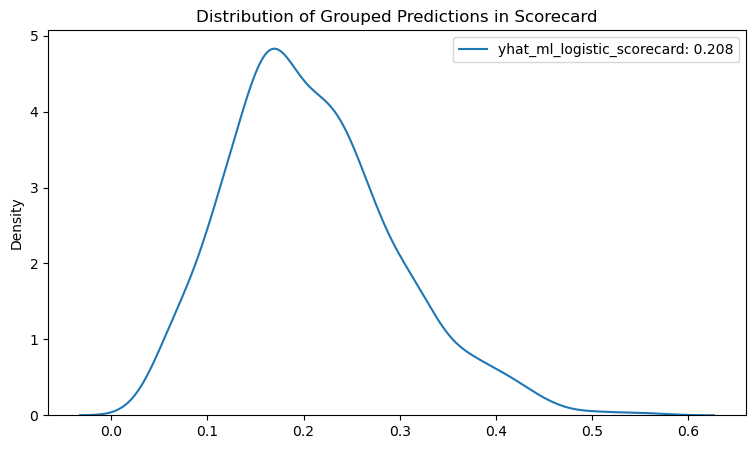

In [15]:
col = 'yhat_ml_logistic_scorecard'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distribution of Grouped Predictions in Scorecard')
flt_mn = df_tmp[col].mean()
str_label = f'{col}: {flt_mn:0.3f}'
sns.kdeplot(list(df_tmp[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()

#### Get quantiles for each set of predictions

In [16]:
list_cols = [
    'yhat_ml_logistic_scorecard',
]
for col in tqdm(list_cols):
    # ml
    arr_score_quantiles = np.percentile(
        list(df_tmp[col]),
        np.linspace(0, 100, 100),
    )
    # save
    str_filename = f'arr_score_quantiles_{col}.pkl'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    pickle.dump(arr_score_quantiles, open(str_local_path, 'wb'))

100%|██████████| 1/1 [00:00<00:00, 789.29it/s]
